Run the whole notebook if the session crashes

## Load Data

In [2]:
!pip install emnist

import gzip
import matplotlib.pyplot as plt
import numpy as np
import struct
import os
import random
import time

import keras
from keras.models import load_model
from keras.models import Sequential
from keras.layers import Dense
# keras.callbacks import ModelCheckpoint
from keras.callbacks import TensorBoard
from keras import backend
from keras.utils import to_categorical

import emnist

%matplotlib inline

In [3]:
path = '/content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/'

In [4]:
# The read_idx function is no longer needed as emnist.load_data() handles data loading directly.

In [27]:
import os
import gzip
import struct
import numpy as np
# No need for shutil, subprocess, requests, tqdm, zipfile anymore for this method

def read_idx(filename):
    """
    Reads an IDX file (MNIST/EMNIST format) and returns a numpy array.
    Supports both image (idx3-ubyte) and label (idx1-ubyte) files, which are gzipped.
    """
    with gzip.open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_emnist():
    """Loads the EMNIST 'bymerge' dataset from Google Drive (chunked files)."""

    # Assuming 'path' is defined globally in the notebook (cell GwlpXbvNxtnm)
    global path # Ensure 'path' is accessible
    if 'path' not in globals():
        print("Warning: 'path' variable not found. Using a default Google Drive path. Please ensure your drive is mounted.")
        path = '/content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/' # Default if not found

    split_dir = os.path.join(path, 'gzip', 'gzip', 'split_emnist')

    print(f"Loading EMNIST data from {split_dir}...")

    # Load training data chunks
    raw_train_X_chunks = []
    raw_train_Y_chunks = []
    num_train_chunks = 8 # Based on filenames 'chunk-0-of-8'
    for i in range(num_train_chunks):
        train_images_path = os.path.join(split_dir, f'emnist-bymerge-train-images-chunk-{i}-of-8.idx3-ubyte.gz')
        train_labels_path = os.path.join(split_dir, f'emnist-bymerge-train-labels-chunk-{i}-of-8.idx1-ubyte.gz')

        print(f"Loading train chunk {i+1}/{num_train_chunks}...")
        raw_train_X_chunks.append(read_idx(train_images_path))
        raw_train_Y_chunks.append(read_idx(train_labels_path))

    raw_train_X = np.concatenate(raw_train_X_chunks, axis=0)
    raw_train_Y = np.concatenate(raw_train_Y_chunks, axis=0)

    # Load test data chunks
    raw_test_X_chunks = []
    raw_test_Y_chunks = []
    num_test_chunks = 2 # Based on filenames 'chunk-0-of-2'
    for i in range(num_test_chunks):
        test_images_path = os.path.join(split_dir, f'emnist-bymerge-test-images-chunk-{i}-of-2.idx3-ubyte.gz')
        test_labels_path = os.path.join(split_dir, f'emnist-bymerge-test-labels-chunk-{i}-of-2.idx1-ubyte.gz')

        print(f"Loading test chunk {i+1}/{num_test_chunks}...")
        raw_test_X_chunks.append(read_idx(test_images_path))
        raw_test_Y_chunks.append(read_idx(test_labels_path))

    raw_test_X = np.concatenate(raw_test_X_chunks, axis=0)
    raw_test_Y = np.concatenate(raw_test_Y_chunks, axis=0)

    print("EMNIST data loaded successfully from Google Drive.")
    return raw_train_X, raw_train_Y, raw_test_X, raw_test_Y

In [28]:
raw_train_X, raw_train_Y, raw_test_X, raw_test_Y = load_emnist()

Loading EMNIST data from /content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/gzip/gzip/split_emnist...
Loading train chunk 1/8...
Loading train chunk 2/8...
Loading train chunk 3/8...
Loading train chunk 4/8...
Loading train chunk 5/8...
Loading train chunk 6/8...
Loading train chunk 7/8...
Loading train chunk 8/8...
Loading test chunk 1/2...
Loading test chunk 2/2...
EMNIST data loaded successfully from Google Drive.


### Verify Split Files

In [ ]:
split_dir = '/content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/gzip/gzip/split_emnist/'
print(f"Listing contents of: {split_dir}")
if os.path.exists(split_dir):
    for filename in os.listdir(split_dir):
        print(filename)
else:
    print(f"Directory not found: {split_dir}")

Listing contents of: /content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/gzip/gzip/split_emnist/
emnist-bymerge-train-images-chunk-0-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-0-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-1-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-1-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-2-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-2-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-3-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-3-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-4-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-4-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-5-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-5-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-6-of-8.idx3-ubyte.gz
emnist-bymerge-train-labels-chunk-6-of-8.idx1-ubyte.gz
emnist-bymerge-train-images-chunk-7-of-8.idx3-ubyte.gz
emnist-bymerge-train-la

In [ ]:
labels = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'

## Prepare Data

In [ ]:
train_X = raw_train_X.reshape(len(raw_train_X), 28, 28, 1)
test_X = raw_test_X.reshape(len(raw_test_X), 28, 28, 1)
type(train_X)

numpy.ndarray

Normalize Pixel Values

In [ ]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')

In [ ]:
#images_to_train.shape

In [ ]:
print(raw_train_Y)

labels = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'
n_cat = len(labels)
n_cat

[24 36  5 ...  9 36  1]


47

In [ ]:
train_y = to_categorical(raw_train_Y, num_classes=n_cat)
test_y = to_categorical(raw_test_Y, num_classes=n_cat)
print(train_y.shape)
print(test_y.shape)

(697932, 47)
(116323, 47)


## Define and Compile the Model

Load Previous Model

In [ ]:
'''model = keras.models.load_model(path + 'model_4_15.keras')
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])'''

"model = keras.models.load_model(path + 'model_4_15.keras')\nmodel.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])"

In [ ]:
'''
model = keras.models.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        keras.layers.MaxPool2D(2, 2),
        keras.layers.BatchNormalization(),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='sigmoid'),
        keras.layers.Dense(47, activation='softmax') # 47 classes for EMNIST ByMerge
])

model = keras.models.Sequential()
model.add(Dense(16, input_dim=784, activation='relu'))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(20, activation = 'relu'))
model.add(Dense(n_cat, activation = 'softmax'))
'''

#print(model)

"\nmodel = keras.models.Sequential([\n        keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),\n        keras.layers.MaxPool2D(2, 2),\n        keras.layers.BatchNormalization(),\n        keras.layers.Flatten(),\n        keras.layers.Dense(128, activation='sigmoid'),\n        keras.layers.Dense(47, activation='softmax') # 47 classes for EMNIST ByMerge\n])\n\nmodel = keras.models.Sequential()\nmodel.add(Dense(16, input_dim=784, activation='relu'))\nmodel.add(Dense(32, activation = 'relu'))\nmodel.add(Dense(20, activation = 'relu'))\nmodel.add(Dense(n_cat, activation = 'softmax'))\n"

In [ ]:
from keras.layers import Input

'''model_suggested = keras.models.Sequential([
    Input(shape=(28, 28, 1)), # Using Input layer as suggested by Keras
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(n_cat, activation='softmax') # n_cat should be 47 for EMNIST ByMerge
])'''

model_suggested = keras.models.load_model(path + 'model_final.keras')

model_suggested.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,423 (2.63 MB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 459,616 (1.75 MB)

In [ ]:
model_suggested.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Train Model

Train Model on Training Dataset and Save the Model



In [17]:
t_start = time.perf_counter()

# Ensure n_cat is defined here for robustness
labels = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'
n_cat = len(labels)

print("\nUsing the pre-loaded full EMNIST training dataset for training...")

# The full raw_train_X and raw_train_Y were loaded globally by FxBJTAl70Khi
# Reshape and normalize the data
combined_train_X = raw_train_X.reshape(len(raw_train_X), 28, 28, 1)
combined_train_X = combined_train_X.astype('float32')
# Convert labels to categorical format
combined_train_Y = to_categorical(raw_train_Y, num_classes=n_cat)

print("\nStarting training on the combined dataset...")
history = model_suggested.fit(
    combined_train_X, combined_train_Y,
    batch_size=128,
    epochs=1, # You can adjust the number of epochs here
    verbose=1
)

print(f"\nFinished training on the combined dataset.")
print(f"Total training time: {int((time.perf_counter() - t_start) / 60)} minutes and {int((time.perf_counter() - t_start) % 60)} seconds.")

model_suggested.save(path + 'model_suggested_5_22.keras')
print("Model saved successfully.")


Using the pre-loaded full EMNIST training dataset for training...


NameError: name 'raw_train_X' is not defined

## Inspect Model Performance

In [ ]:
#results = model_suggested.evaluate(test_X, test_y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


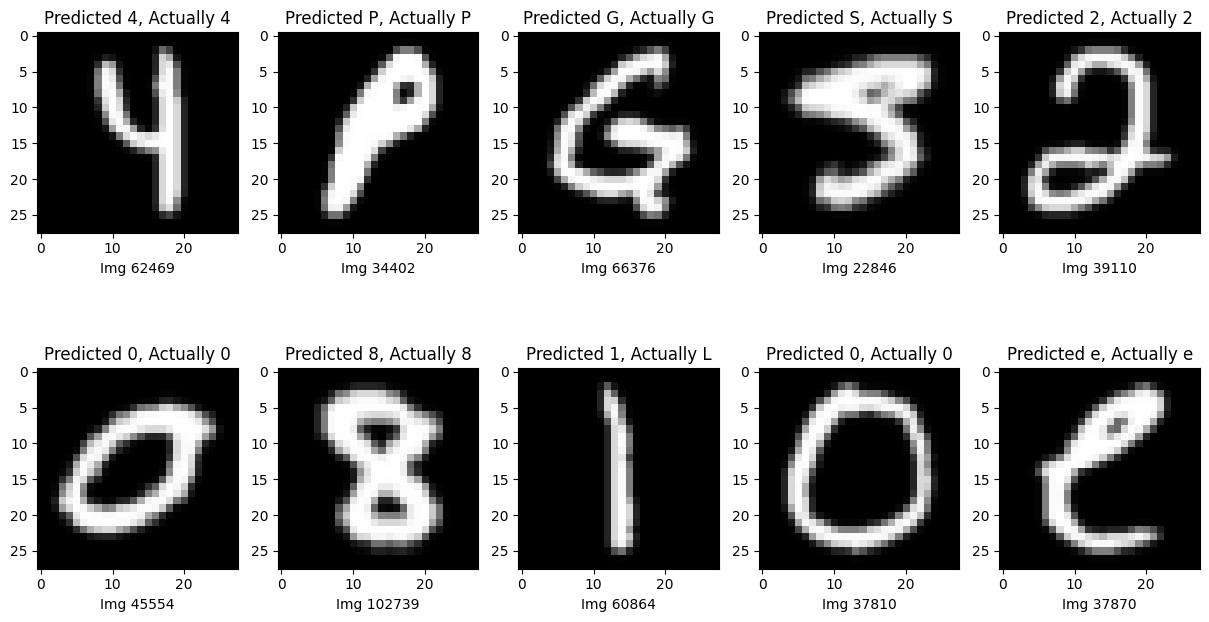

In [ ]:
random.seed(123456)
sample = np.arange(raw_test_X.shape[0])
np.random.shuffle(sample)
sample = sample[0:10]

results = np.round(model_suggested.predict(test_X[sample], verbose=1), decimals=2)
resultLabels = np.argmax(results, axis = 1)

fig = plt.figure(figsize=(15,8))
for i in range(10):
  fig.add_subplot(2,5,i+1,aspect='equal')
  plt.imshow(raw_test_X[sample[i]].T, cmap = 'gray')
  string = 'Predicted {}'.format(labels[resultLabels[i]]) +', Actually ' + labels[raw_test_Y[sample[i]]]
  plt.title(string)
  plt.xlabel('Img {}'.format(sample[i]))


## Load Image and Find Contours

Image loaded successfully from /content/drive/MyDrive/test_example.jpg


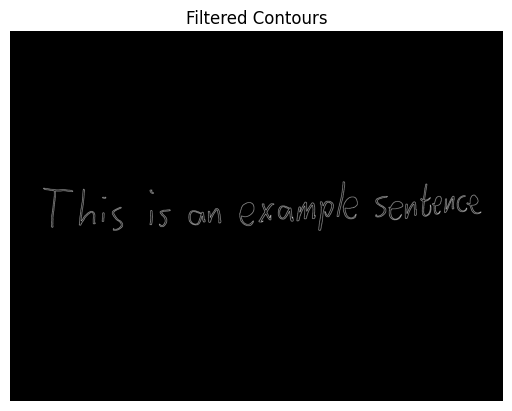

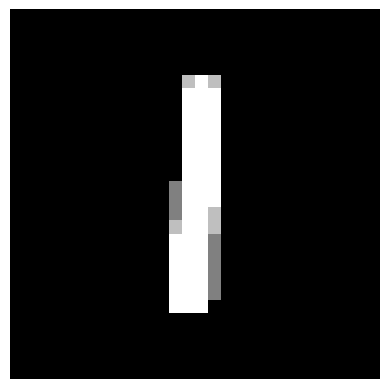

I


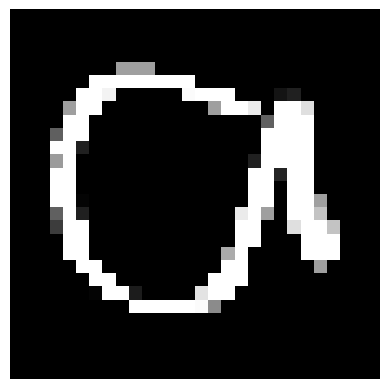

a


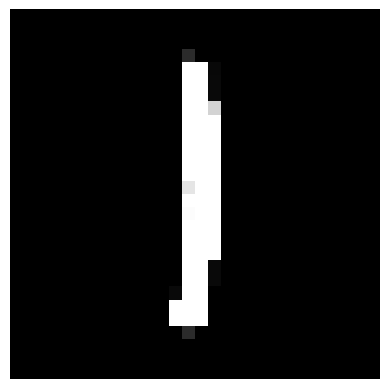

L


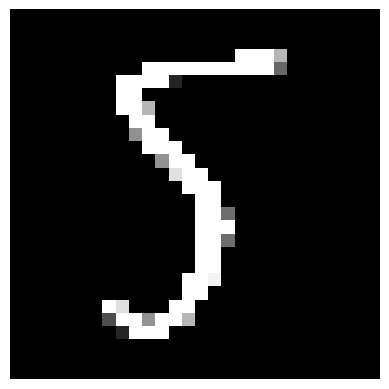

5


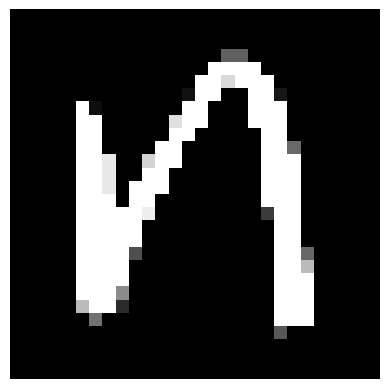

M


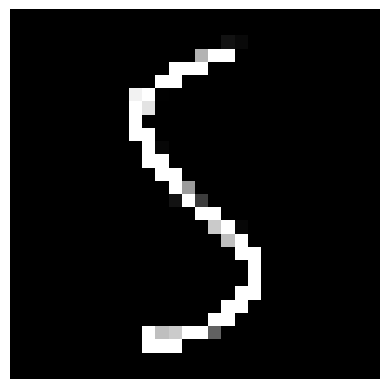

S


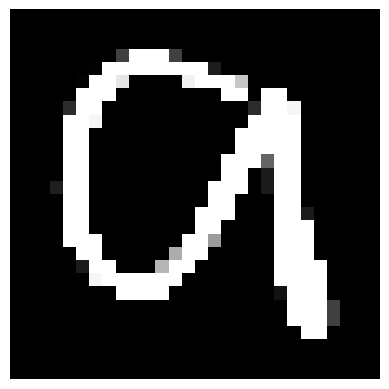

0


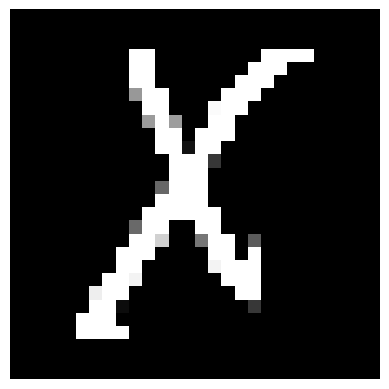

X


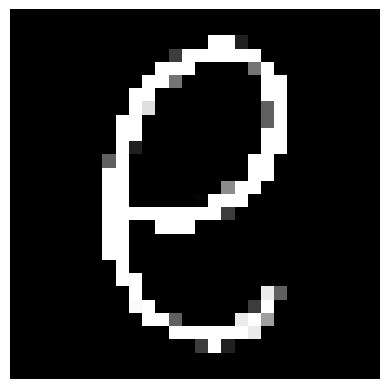

e


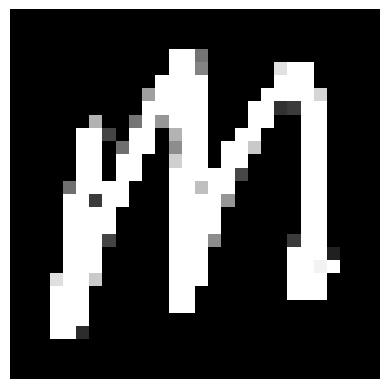

M


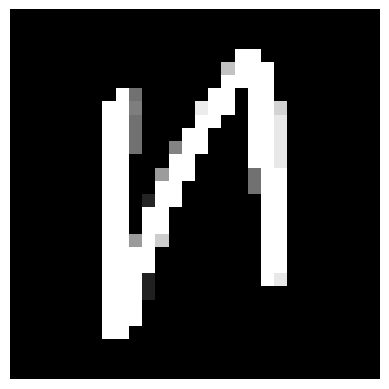

M


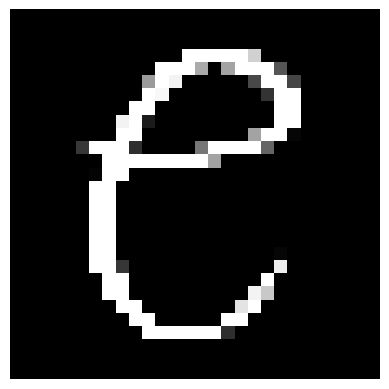

e


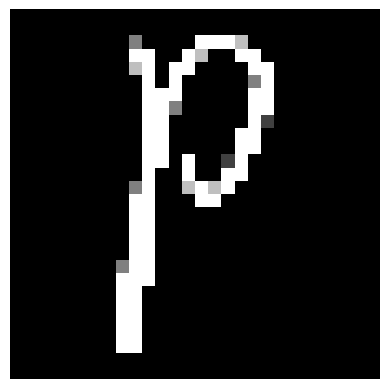

P


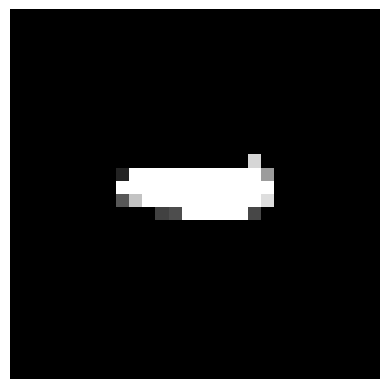

t


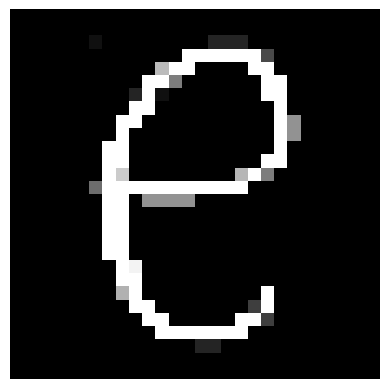

e


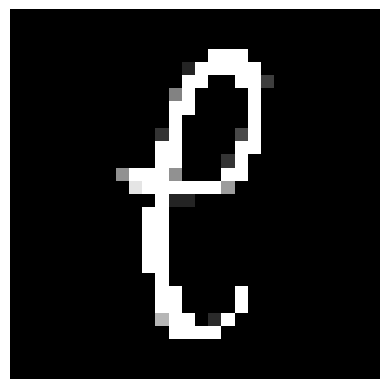

F


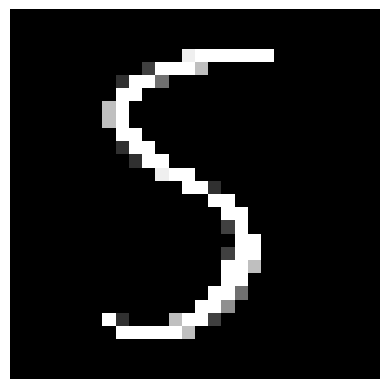

S


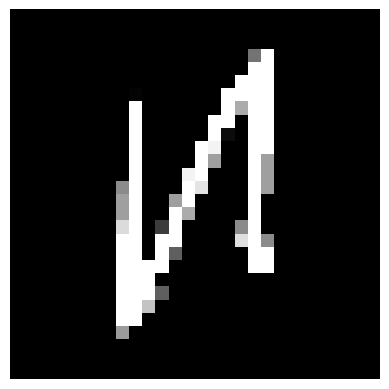

H


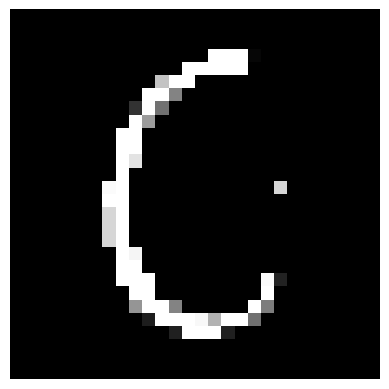

C


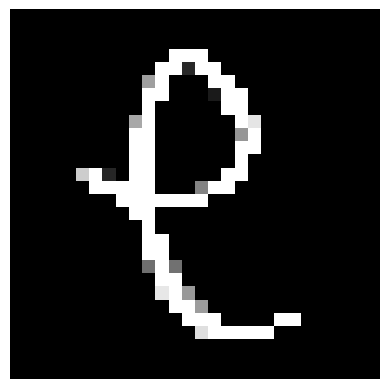

R


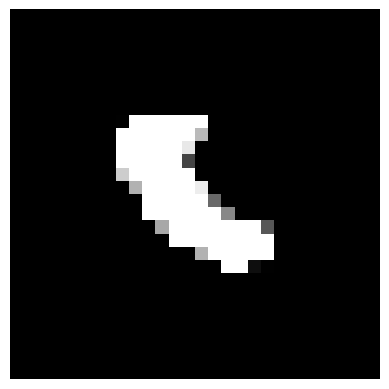

F


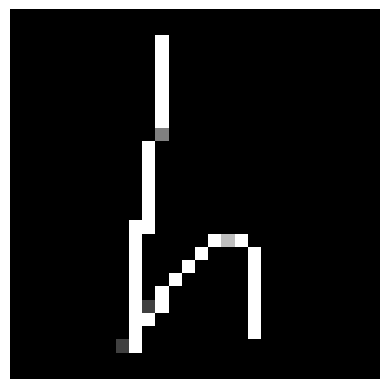

h


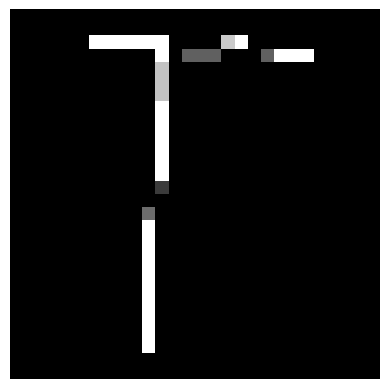

Y


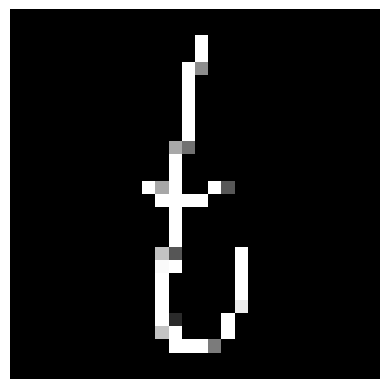

t


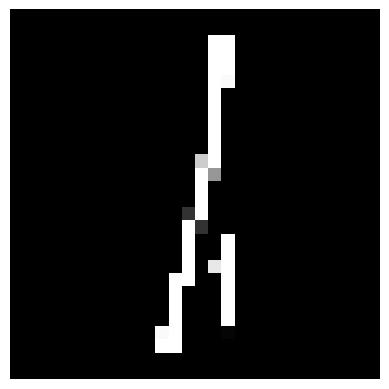

h
Predicted labels for all contours: ['I', 'a', 'L', '5', 'M', 'S', '0', 'X', 'e', 'M', 'M', 'e', 'P', 't', 'e', 'F', 'S', 'H', 'C', 'R', 'F', 'h', 'Y', 't', 'h']
23
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
import matplotlib.pyplot as plt
import cv2

image_path = '/content/drive/MyDrive/test_example.jpg'
try:
    image = cv2.imread(image_path)
    image = cv2.bitwise_not(image)
    print(f"Image loaded successfully from {image_path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    white_image = np.full_like(image, 0)



except FileNotFoundError:
    print(f"Error: File not found at {image_path}")
except Exception as e:
    print(f"An error occurred: {e}")

predicted_labels = []
contour_bboxes = []


min_contour_area = 60
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]


filtered_contour_image = np.full_like(image, 0)
cv2.drawContours(filtered_contour_image, filtered_contours, -1, (255, 255, 255), 2)
plt.imshow(filtered_contour_image)
plt.axis('off')
plt.title('Filtered Contours')
plt.show()

images_to_train = []

for i, contour in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(contour)
    contour_bboxes.append((x, y, w, h))


    contour_roi = gray[y:y+h, x:x+w]


    ret_roi, thresh_roi = cv2.threshold(contour_roi, 127, 255, cv2.THRESH_BINARY)



    padding = 20
    max_dim = max(w, h)
    temp_img_size = max_dim + 2 * padding
    temp_img = np.zeros((temp_img_size, temp_img_size), dtype=np.uint8)


    paste_x = padding + (max_dim - w) // 2
    paste_y = padding + (max_dim - h) // 2


    temp_img[paste_y:paste_y + h, paste_x:paste_x + w] = thresh_roi


    temp_img_r = cv2.resize(temp_img, (28, 28))


    #transposed_img = temp_img_r.T
    flipped_img = np.flipud(temp_img_r)
    transformed_img = np.rot90(flipped_img, k=-1)


    final_img = transformed_img.reshape(28, 28, 1)


    final_img = final_img.astype('float32')

    images_to_train.append(final_img)


    img_for_prediction = final_img.reshape(1, 28, 28, 1)

    results = model_suggested.predict(img_for_prediction, verbose=0)

    resultLabels = np.argmax(results, axis = 1)

    plt.imshow(temp_img_r, cmap='gray')
    plt.axis('off')
    plt.show()
    print(labels[resultLabels[0]])


    predicted_labels.append(labels[resultLabels[0]])

images_to_train = np.array(images_to_train)
print("Predicted labels for all contours:", predicted_labels)
act_lbls = ['I', 'a', 'I', 'S', 'n', 'S', 'a', 'X', 'e', 'M', 'n', 'e', 'P', 'e', 'e', 'S', 'n', 'C', 'e', 'h', 'T', 't', 'L']
print(len(act_lbls))
train_imgs_lbls = [labels.index(act_lbls[i]) for i in range(len(act_lbls))]
train_imgs_lbls = to_categorical(train_imgs_lbls, num_classes = 47)
print(train_imgs_lbls)

In [ ]:
print(images_to_train.shape)
print(train_X.shape)

(25, 28, 28, 1)
(697932, 28, 28, 1)


#Order the predicted labels based on the position of their corresponding bounding boxes in the image

Shape before transpose: (28, 28, 1)


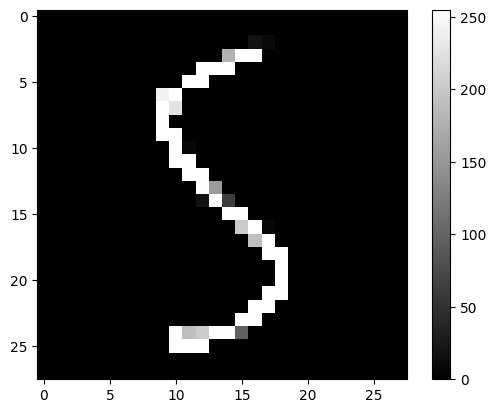

In [ ]:
image_to_display = images_to_train[5]

print("Shape before transpose:", image_to_display.shape)

image_to_display_2d = image_to_display.reshape(28, 28)

plt.imshow(image_to_display_2d.T, cmap = 'gray')
plt.colorbar()
plt.show()

In [ ]:
print("Shape of images_to_train:", images_to_train.shape)
print("Dtype of images_to_train:", images_to_train.dtype)
print("Shape of train_imgs_lbls:", train_imgs_lbls.shape)
print("Dtype of train_imgs_lbls:", train_imgs_lbls.dtype)
#results = model.evaluate(images_to_train, train_imgs_lbls)

Shape of images_to_train: (25, 28, 28, 1)
Dtype of images_to_train: float32
Shape of train_imgs_lbls: (23, 47)
Dtype of train_imgs_lbls: float64


In [ ]:
'''t_start = time.perf_counter()
model.fit(images_to_train, train_imgs_lbls, 25, 1)
print(time.perf_counter() - t_start)'''

't_start = time.perf_counter()\nmodel.fit(images_to_train, train_imgs_lbls, 25, 1)\nprint(time.perf_counter() - t_start)'

In [ ]:
import matplotlib.pyplot as plt
import cv2
import statistics
t_start = time.perf_counter()
image_path = '/content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/train/tnr_alt1_1.png'
try:
    image = cv2.imread(image_path)
    image = cv2.bitwise_not(image)
    print(f"Image loaded successfully from {image_path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    white_image = np.full_like(image, 0)

except FileNotFoundError:
    print(f"Error: File not found at {image_path}")
except Exception as e:
    print(f"An error occurred: {e}")

# --- Start of modified section for contour processing and ordering ---
contour_bboxes = []
min_contour_area = 1000
filtered_contours = [contour for contour in contours if cv2.contourArea(contour) > min_contour_area]

for contour in filtered_contours:
    x, y, w, h = cv2.boundingRect(contour)
    contour_bboxes.append((x, y, w, h))
plt.imshow(cv2.bitwise_not(image))
plt.axis('off')
plt.title('Original Image')
plt.show()

filtered_contour_image = np.full_like(image, 0)
cv2.drawContours(filtered_contour_image, filtered_contours, -1, (255, 255, 255), 2)
plt.imshow(filtered_contour_image)
plt.axis('off')
plt.title('Filtered Contours')
plt.show()


lines = []
for bbox in contour_bboxes:
    x, y, w, h = bbox
    added_to_line = False
    i = 0
    line_match = []
    for line in lines:
        line_overlap = False
        for line_bbox in line:
            line_x, line_y, line_w, line_h = line_bbox
            if y <= line_y + line_h and line_y <= y + h:
                line_overlap = True
        if line_overlap:
            line_match.append(i)
            added_to_line = True
        i += 1
    # print(line_match) # Commented out verbose printing
    if added_to_line:
        lines[line_match[0]].append(bbox)
        if len(line_match) >= 2:
            # print('line_match greater than 2') # Commented out verbose printing
            new_line = []
            for indx in line_match:
                new_line += lines[indx]
            # print('newline', len(new_line)) # Commented out verbose printing
            lines[line_match[0]] = new_line
            for i in range(len(line_match) - 1):
                lines.remove(lines[line_match[i + 1]])
    else:
        lines.append([bbox])
    # print(lines) # Commented out verbose printing

print("Lines before reversal (bottom to top):", lines)
lines.reverse() # Reverse the order of lines to be top-to-bottom
print("Lines after reversal (top to bottom):", lines)

new_filtered_contours = []
for line in lines:
  ls = []
  for bbox in line:
    b = True
    for n, bbox2 in enumerate(ls):
      if bool(bbox[0] <= bbox2[0] + bbox2[2]) == bool(bbox[0] + bbox2[2] >= bbox2[0]):
        if not((bbox[1] > bbox2[1] and bbox[1] < bbox2[1] + bbox2[3]) or (bbox[1] < bbox2[1] and bbox[1] + bbox[3] > bbox2[1])):
          x, y, w, h = min(bbox[0], bbox2[0]), min(bbox[1], bbox2[1]), max(bbox[0], bbox2[0]) + max(bbox[2], bbox2[2]) - min(bbox[0], bbox2[0]), max(bbox[1], bbox2[1]) + max(bbox[3], bbox2[3]) - min(bbox[1], bbox2[1])
          ls[n] = (x, y, w, h)
          b = False
          print("smushed")
    if b:
      ls.append(bbox)
  new_filtered_contours.append(ls)

print("New filtered contours (should be top to bottom):", new_filtered_contours)

# Initialize lists to store processed images and their predictions in order
images_to_train_list_temp = []
predicted_labels = [] # This will be a list of lists, where each inner list corresponds to a line
char_bbox_mapping = [] # Initialize char_bbox_mapping here

for line_contours in new_filtered_contours:
  current_line_char_data = [] # Stores {'bbox', 'img', 'label'} for characters in the current line
  current_line_predicted_labels_for_display = []
  current_line_char_bbox_mapping_entries = [] # To store (char, bbox) for this line, correctly paired and sorted

  for bbox_item in line_contours:
    x, y, w, h = bbox_item
    contour_roi = gray[y:y+h, x:x+w]
    ret_roi, thresh_roi = cv2.threshold(contour_roi, 150, 255, cv2.THRESH_BINARY)
    padding = 20
    max_dim = max(w, h)
    temp_img_size = max_dim + 2 * padding
    temp_img = np.zeros((temp_img_size, temp_img_size), dtype=np.uint8)

    paste_x = padding + (max_dim - w) // 2
    paste_y = padding + (max_dim - h) // 2

    temp_img[paste_y:paste_y + h, paste_x:paste_x + w] = thresh_roi
    temp_img_r = cv2.resize(temp_img, (28, 28))
    flipped_img = np.flipud(temp_img_r)
    transformed_img = np.rot90(flipped_img, k=-1)
    final_img = transformed_img.reshape(28, 28, 1)
    final_img = final_img.astype('float32')

    img_for_prediction = final_img.reshape(1, 28, 28, 1)

    results = model_suggested.predict(img_for_prediction, verbose=0)
    resultLabels = np.argmax(results, axis = 1)
    predicted_char = labels[resultLabels[0]]

    current_line_char_data.append({'bbox': bbox_item, 'img': final_img, 'label': predicted_char})

  # Sort characters within the current line by their x-coordinate
  current_line_char_data.sort(key=lambda item: item['bbox'][0])

  # Now, collect the sorted images and labels for the current line
  for item in current_line_char_data:
      images_to_train_list_temp.append(item['img'])
      current_line_predicted_labels_for_display.append(item['label'])
      current_line_char_bbox_mapping_entries.append((item['label'], item['bbox'])) # Correctly paired char and bbox

      # Optional: Display individual character image and prediction during processing
      plt.imshow(item['img'].reshape(28,28).T, cmap='gray')
      plt.axis('off')
      plt.title(f"Predicted: {item['label']}")
      plt.show()

  predicted_labels.append(current_line_predicted_labels_for_display)
  char_bbox_mapping.append(current_line_char_bbox_mapping_entries) # Populate char_bbox_mapping

# Convert the collected images to a numpy array
images_to_train = np.array(images_to_train_list_temp)

print("Predicted labels for all contours (ordered by line and x-coordinate):", predicted_labels)
# --- End of modified section ---
print("Predicted characters:")
for line in predicted_labels:
  print(" ".join(line))

print("\n")
print("\n")

act_lbls = ['Y', 'Z', 'O', 'a', 'e', 'g', 'T', 'd', 'L', 'h', 'V', 'U', 'J', 'X', 'r', 'e', 'O', 'S', 'P', 'M', 'O', 'F', 'W', 'I', 'U', 'n', 'O', 'r', 'C', 'e', 'q', 'T', 'b', 'K', 'h']
print(len(act_lbls))
train_imgs_lbls = [labels.index(act_lbls[i]) for i in range(len(act_lbls))]
train_imgs_lbls = to_categorical(train_imgs_lbls, num_classes = 47)
#model.fit(images_to_train, train_imgs_lbls, 25, 10)
#results = model.evaluate(images_to_train, train_imgs_lbls)


image_with_predictions = cv2.imread(image_path)
ordered_predictions = []

if image_with_predictions is None:
    print(f"Error: Could not load image from {image_path} for visualization.")
else:
  for g, line_char_bbox_pairs in enumerate(char_bbox_mapping): # Use the correctly ordered char_bbox_mapping
    ordered_predictions.append([])
    # predicted_labels[g] is now correctly ordered by x-coordinate for this line
    for label, bbox in line_char_bbox_pairs: # Each item is now (label, bbox)
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
        x, y, w, h = bbox
        cv2.rectangle(image_with_predictions, (x, y), (x+w, y+h), colors[g % 3], 2)
        text_y = y - 10
        if text_y < 10:
            text_y = y + h + 20
        cv2.putText(image_with_predictions, label, (x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 10)
        tup = (x, label, x + w)
        ordered_predictions[g].append(tup)

    plt.figure(figsize=(30, 30))
    plt.imshow(cv2.cvtColor(image_with_predictions, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Image with Predicted Characters')
    plt.show()

# Removed the `chars` calculation and printing block here.
# The final, refined text will be printed at the end of the notebook after all case/size analyses.

# The actual ground truth labels for a specific image, likely for evaluation
act_lbls = ['A', 'b', 'C', 'd', 'E', 'f', 'G', 'h', 'I', 'J', 'K', 'L', 'M', 'n', 'O', 'P', 'Q', 'r', 'S', 't', 'U', 'V', 'W', 'X', 'Y', 'Z']
print(len(act_lbls))
train_imgs_lbls = [labels.index(act_lbls[i]) for i in range(len(act_lbls))]
train_imgs_lbls = to_categorical(train_imgs_lbls, num_classes = 47)
i = 0
'''for ige in images_to_train:
  plt.imshow(ige)
  plt.axis('off')
  plt.title(act_lbls[i])
  plt.show()
  i += 1'''
'''model_suggested.fit(images_to_train, train_imgs_lbls, 26, 3)
results = model_suggested.evaluate(images_to_train, train_imgs_lbls)'''
model_suggested.save(path + 'model_final.keras')

print(time.perf_counter() - t_start)


Output hidden; open in https://colab.research.google.com to view.

#Identify and Address Context Cases

In [ ]:
context_cases = [['C', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'S', 'U', 'V', 'W', 'X', 'Y', 'Z'], ['c', 'i', 'j', 'k', 'l', 'm', 'o', 'p', 's', 'u', 'v', 'w', 'x', 'y', 'z']]
predicted = [item for sublist in predicted_labels for item in sublist]
ls = [ch for i, ch in enumerate(predicted) if ch in context_cases[0]]
print(ls)
print(predicted)

['C', 'I', 'J', 'K', 'M', 'P', 'I', 'S', 'Y', 'W', 'X', 'Y', 'Z']
['A', 'h', 'C', 'd', 'R', 'F', 'G', 'h', 'I', 'J', 'K', '1', 'M', 'N', '0', 'P', 'a', 'I', 'S', 't', '0', 'Y', 'W', 'X', 'Y', 'Z']


In [ ]:
def find_context_cases(predicted_chars, context_cases):
    context_sensitive_chars = []
    uppercase_context = set(context_cases[0]) # Convert to set for faster lookup
    lowercase_context = set(context_cases[1]) # Convert to set for faster lookup

    for line_of_chars in predicted_chars:
        for char in line_of_chars:
            # Check if the character (ignoring spaces) is in either context set
            if char != ' ' and (char in uppercase_context or char in lowercase_context):
                context_sensitive_chars.append(char)
    return context_sensitive_chars

In [ ]:
identified_context_chars = find_context_cases(predicted, context_cases)
print("Identified Context-Sensitive Characters:", identified_context_chars)

Identified Context-Sensitive Characters: ['C', 'I', 'J', 'K', 'M', 'P', 'I', 'S', 'Y', 'W', 'X', 'Y', 'Z']


In [ ]:
char_bbox_mapping_with_spaces = [] # New variable to store the mapping after space insertion

for line_idx in range(len(char_bbox_mapping)):
    # Use the already correctly structured char_bbox_mapping
    temp_line_data = char_bbox_mapping[line_idx]

    # 1. Collect all character widths and inter-character gaps for the current line
    current_line_char_widths = []
    current_line_gaps = []
    prev_char_end = None # Tracks the rightmost edge of previous character

    for item in temp_line_data:
        char, bbox = item
        if bbox is not None: # It's an actual character
            x, y, w, h = bbox
            current_line_char_widths.append(w)
            if prev_char_end is not None:
                gap = x - prev_char_end
                if gap > 0: # Only consider positive gaps
                    current_line_gaps.append(gap)
            prev_char_end = x + w

    # 2. Calculate adaptive parameters for space detection
    avg_char_w = statistics.mean(current_line_char_widths) if current_line_char_widths else 0

    if current_line_gaps:
        # Use the median of all positive gaps as a baseline for typical character separation
        median_inter_char_gap = np.median(current_line_gaps)
    else:
        # Fallback if no gaps observed, use a small fraction of avg_char_w
        median_inter_char_gap = avg_char_w * 0.2

    # Define a dynamic threshold for space insertion
    # A gap is considered a space if it's significantly larger than the median inter-character gap
    # and also a certain fraction of the average character width.
    # The factor (e.g., 1.8x) can be tuned. 'max' ensures a meaningful minimum gap for a space.
    space_detection_threshold_factor = 1.8
    space_threshold = max(median_inter_char_gap * space_detection_threshold_factor, avg_char_w * 0.7)

    # e. Initialize an empty list for the current line's structured data
    final_line_mapping = []
    prev_x_plus_w = None # Tracks the rightmost edge of the LAST *character*

    # f. Iterate through the sorted temp_line_data to insert spaces with adaptive logic
    for item in temp_line_data: # Iterate over the item (char, bbox) directly
        char, bbox = item # Unpack item here

        # Only process character-specific logic if it's not a space (i.e., bbox is not None)
        if bbox is not None:
            x, y, w, h = bbox

            # ii. If it's not the first *character* in the line, calculate the horizontal gap
            # (i.e., prev_x_plus_w has been set by a previous character)
            if prev_x_plus_w is not None:
                gap = x - prev_x_plus_w
                # iii. If gap is greater than the adaptive space_threshold, append appropriate number of spaces
                if gap > space_threshold:
                    num_spaces = int(round(gap / avg_char_w))
                    if num_spaces == 0: # Ensure at least one space if threshold is met
                        num_spaces = 1
                    final_line_mapping.append((' ' * num_spaces, None))

            # iv. Append the current character and its bounding box
            final_line_mapping.append((char, bbox))

            # v. Update prev_x_plus_w with the rightmost edge of the current character
            prev_x_plus_w = x + w
        else:
            # This item is a space (bbox is None). Just append it directly.
            final_line_mapping.append(item) # Append (char, None) directly
            # Do NOT update prev_x_plus_w. It should retain the value from the last actual character.

    # g. Append final_line_mapping to char_bbox_mapping_with_spaces
    char_bbox_mapping_with_spaces.append(final_line_mapping)

# Now, assign the processed mapping back to char_bbox_mapping for consistency
char_bbox_mapping = char_bbox_mapping_with_spaces

# 4. Print the char_bbox_mapping to review the structured output.
print("Character to Bounding Box Mapping (including spaces):")
for line in char_bbox_mapping:
    print(line)

Character to Bounding Box Mapping (including spaces):
[('A', (457, 720, 300, 277)), ('h', (868, 705, 196, 293)), ('C', (1202, 717, 241, 280)), ('d', (1586, 700, 191, 295)), ('R', (1895, 714, 224, 276)), ('F', (2255, 692, 127, 295)), ('G', (2503, 708, 273, 279)), ('h', (2893, 693, 206, 287)), ('I', (3214, 708, 119, 270)), ('J', (3438, 705, 127, 360))]
[('K', (393, 1276, 292, 280)), ('1', (802, 1258, 102, 295)), ('M', (1030, 1271, 355, 280)), ('N', (1511, 1346, 197, 200)), ('0', (1836, 1264, 268, 281)), ('P', (2232, 1340, 185, 288)), ('a', (2555, 1257, 288, 345)), ('I', (2957, 1333, 131, 200)), ('S', (3222, 1251, 184, 283)), ('t', (3534, 1291, 115, 240))]
[('0', (953, 1830, 291, 287)), ('Y', (1359, 1909, 221, 204)), ('W', (1679, 1818, 399, 292)), ('X', (2189, 1900, 251, 200)), ('Y', (2503, 1815, 294, 283)), ('Z', (2932, 1897, 166, 199))]


In [ ]:
uppercase_heights = []
lowercase_heights = []

# Define known uppercase and lowercase characters based on the 'labels' string
known_uppercase_chars = labels[10:36]  # 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
known_lowercase_chars = labels[36:]  # 'abdefghnqrt'

# Iterate through each line and then each character-bbox pair in the char_bbox_mapping.
for line in char_bbox_mapping:
    for char, bbox in line:
        # Check if the character is not a space (' ') and if its bounding box is not None.
        if char != ' ' and bbox is not None:
            # If the character is a known uppercase character, append its height.
            if char in known_uppercase_chars:
                uppercase_heights.append(bbox[3])
            # If the character is a known lowercase character, append its height.
            elif char in known_lowercase_chars:
                lowercase_heights.append(bbox[3])

# Calculate the avg_uppercase_height and avg_lowercase_height.
# Handle cases where a list might be empty to avoid division by zero.
avg_uppercase_height = np.mean(uppercase_heights) if uppercase_heights else 0
avg_lowercase_height = np.mean(lowercase_heights) if lowercase_heights else 0

# Define a function named predict_case_by_size.
def predict_case_by_size(bbox, avg_uppercase_height, avg_lowercase_height):
    # Inside the predict_case_by_size function, if the bbox is None, return None.
    if bbox is None:
        return None

    # Otherwise, extract the character's height from the bbox (bbox[3]).
    char_height = bbox[3]

    # Compare the character's height to the calculated avg_uppercase_height and avg_lowercase_height
    # to determine its likely case.
    # Using a simple comparison: closer to which average height.
    if avg_uppercase_height == 0 and avg_lowercase_height == 0: # Fallback if no averages calculated
        return None # Cannot predict without reference
    elif avg_uppercase_height == 0: # Only lowercase average available
        return 'lower'
    elif avg_lowercase_height == 0: # Only uppercase average available
        return 'upper'
    else:
        if abs(char_height - avg_uppercase_height) < abs(char_height - avg_lowercase_height):
            return 'upper'
        else:
            return 'lower'

# Print the calculated avg_uppercase_height and avg_lowercase_height.
print(f"Average Uppercase Height: {avg_uppercase_height:.2f}")
print(f"Average Lowercase Height: {avg_lowercase_height:.2f}")

Average Uppercase Height: 263.67
Average Lowercase Height: 292.00


In [ ]:
uppercase_heights = []
lowercase_heights = []

# Define known uppercase and lowercase characters based on the 'labels' string
known_uppercase_chars = labels[10:36]  # 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
known_lowercase_chars = labels[36:]  # 'abdefghnqrt'

# Iterate through each line and then each character-bbox pair in the char_bbox_mapping.
for line in char_bbox_mapping:
    for char, bbox in line:
        # Check if the character is not a space (' ') and if its bounding box is not None.
        if char != ' ' and bbox is not None:
            # If the character is a known uppercase character, append its height.
            if char in known_uppercase_chars:
                uppercase_heights.append(bbox[3])
            # If the character is a known lowercase character, append its height.
            elif char in known_lowercase_chars:
                lowercase_heights.append(bbox[3])

# Calculate the avg_uppercase_height and avg_lowercase_height.
# Handle cases where a list might be empty to avoid division by zero.
avg_uppercase_height = np.mean(uppercase_heights) if uppercase_heights else 0
avg_lowercase_height = np.mean(lowercase_heights) if lowercase_heights else 0

# Define a function named predict_case_by_size.
def predict_case_by_size(bbox, avg_uppercase_height, avg_lowercase_height):
    # Inside the predict_case_by_size function, if the bbox is None, return None.
    if bbox is None:
        return None

    # Otherwise, extract the character's height from the bbox (bbox[3]).
    char_height = bbox[3]

    # Compare the character's height to the calculated avg_uppercase_height and avg_lowercase_height
    # to determine its likely case.
    # Using a simple comparison: closer to which average height.
    if avg_uppercase_height == 0 and avg_lowercase_height == 0: # Fallback if no averages calculated
        return None # Cannot predict without reference
    elif avg_uppercase_height == 0: # Only lowercase average available
        return 'lower'
    elif avg_lowercase_height == 0: # Only uppercase average available
        return 'upper'
    else:
        if abs(char_height - avg_uppercase_height) < abs(char_height - avg_lowercase_height):
            return 'upper'
        else:
            return 'lower'

# Print the calculated avg_uppercase_height and avg_lowercase_height.
print(f"Average Uppercase Height: {avg_uppercase_height:.2f}")
print(f"Average Lowercase Height: {avg_lowercase_height:.2f}")

Average Uppercase Height: 263.67
Average Lowercase Height: 292.00


In [ ]:
initial_case_predictions_mapping = []

for line in char_bbox_mapping:
    line_predictions = []
    for char, bbox in line:
        if char == ' ':
            # Spaces don't have a case, so we store ' ' and None for bbox and case.
            line_predictions.append({'char': char, 'bbox': None, 'predicted_case': None})
        else:
            # Predict case based on size heuristic
            predicted_case = predict_case_by_size(bbox, avg_uppercase_height, avg_lowercase_height)
            line_predictions.append({'char': char, 'bbox': bbox, 'predicted_case': predicted_case})
    initial_case_predictions_mapping.append(line_predictions)

print("Initial Case Predictions Mapping:")
for line in initial_case_predictions_mapping:
    for item in line:
        print(f"Char: {item['char']}, Predicted Case: {item['predicted_case']}", end="; ")
    print()

Initial Case Predictions Mapping:
Char: A, Predicted Case: upper; Char: h, Predicted Case: lower; Char: C, Predicted Case: lower; Char: d, Predicted Case: lower; Char: R, Predicted Case: upper; Char: F, Predicted Case: lower; Char: G, Predicted Case: lower; Char: h, Predicted Case: lower; Char: I, Predicted Case: upper; Char: J, Predicted Case: lower; 
Char: K, Predicted Case: lower; Char: 1, Predicted Case: lower; Char: M, Predicted Case: lower; Char: N, Predicted Case: upper; Char: 0, Predicted Case: lower; Char: P, Predicted Case: lower; Char: a, Predicted Case: lower; Char: I, Predicted Case: upper; Char: S, Predicted Case: lower; Char: t, Predicted Case: upper; 
Char: 0, Predicted Case: lower; Char: Y, Predicted Case: upper; Char: W, Predicted Case: lower; Char: X, Predicted Case: upper; Char: Y, Predicted Case: lower; Char: Z, Predicted Case: upper; 


In [ ]:
import numpy as np
import copy

# 1. Define a list named descender_chars
# Based on EMNIST ByMerge labels and typical descenders.
# EMNIST ByMerge labels include separate uppercase and lowercase for some, but not all. 'g', 'j', 'p', 'q', 'y'
# are common lowercase descenders. 'Q' might have one, but for simplicity, we'll focus on the most common lowercase ones.
# The 'labels' variable is already defined and available from previous steps.
# labels = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'
descender_chars = ['g', 'j', 'p', 'q', 'y'] # Assuming these are the primary lowercase descenders in EMNIST

# 2. Initialize an empty list called refined_predictions_with_descenders
refined_predictions_with_descenders = []

print(f"Descender characters identified: {descender_chars}")
print("Initialized refined_predictions_with_descenders.")

Descender characters identified: ['g', 'j', 'p', 'q', 'y']
Initialized refined_predictions_with_descenders.


In [ ]:
import copy

def check_and_assign_descender_case(char_data_item, descender_chars, median_baseline, threshold):
    """
    Checks if a character is a hanging descender and, if so, assigns its case to lowercase.

    Args:
        char_data_item (dict): A dictionary containing character data, including 'char', 'bbox', and 'predicted_case'.
        descender_chars (list): A list of characters that are considered descenders.
        median_baseline (float): The median baseline for the current line of text.
        threshold (int): The pixel threshold below the baseline to consider a character 'hanging'.

    Returns:
        dict: The updated character data item with 'predicted_case' potentially modified to 'lower'.
    """
    # Create a deep copy to avoid modifying the original item directly when passing through the function
    refined_char_data = copy.deepcopy(char_data_item)

    char = refined_char_data['char']
    bbox = refined_char_data['bbox']

    # Only process if it's a known descender, has a bounding box, and is not a space
    # Convert char to lowercase for comparison with descender_chars list
    if char != ' ' and bbox is not None and char.lower() in descender_chars:
        # Check if the character's bottom edge is significantly below the median baseline
        if (bbox[1] + bbox[3]) > (median_baseline + threshold):
            refined_char_data['predicted_case'] = 'lower'

    return refined_char_data

In [ ]:
import copy

def check_and_assign_descender_case(char_data_item, descender_chars, median_baseline, threshold):
    """
    Checks if a character is a hanging descender and, if so, assigns its case to lowercase.

    Args:
        char_data_item (dict): A dictionary containing character data, including 'char', 'bbox', and 'predicted_case'.
        descender_chars (list): A list of characters that are considered descenders.
        median_baseline (float): The median baseline for the current line of text.
        threshold (int): The pixel threshold below the baseline to consider a character 'hanging'.

    Returns:
        dict: The updated character data item with 'predicted_case' potentially modified to 'lower'.
    """
    # Create a deep copy to avoid modifying the original item directly when passing through the function
    refined_char_data = copy.deepcopy(char_data_item)

    char = refined_char_data['char']
    bbox = refined_char_data['bbox']

    # Only process if it's a known descender, has a bounding box, and is not a space
    # Convert char to lowercase for comparison with descender_chars list
    if char != ' ' and bbox is not None and char.lower() in descender_chars:
        # Check if the character's bottom edge is significantly below the median baseline
        if (bbox[1] + bbox[3]) > (median_baseline + threshold):
            refined_char_data['predicted_case'] = 'lower'

    return refined_char_data

threshold = 10 # Pixels below baseline to consider a significant descender

refined_predictions_with_descenders = [] # Clear the list at the beginning of execution

# Assuming context_cases is defined globally (from bMg1Nr-RmkDz)
context_upper_set = set(context_cases[0])
context_lower_set = set(context_cases[1]) # This set is not used in the modified logic as requested
digit_set = set('0123456789')

for line_idx, line_data in enumerate(initial_case_predictions_mapping):
    line_baselines = []
    for char_data in line_data:
        char = char_data['char']
        bbox = char_data['bbox']
        # Use char.lower() here too for consistency in identifying non-descender characters for baseline calculation
        if char != ' ' and char.lower() not in descender_chars and bbox is not None:
            line_baselines.append(bbox[1] + bbox[3])

    median_baseline = np.median(line_baselines) if line_baselines else 0

    current_line_refined = []

    for char_idx, char_data in enumerate(line_data):
        refined_char_data = copy.deepcopy(char_data)
        char = refined_char_data['char']
        bbox = refined_char_data['bbox']

        if char == ' ' or bbox is None:
            current_line_refined.append(refined_char_data)
            continue

        # Store the initial predicted_case from the size heuristic before any modifications
        original_predicted_case = char_data['predicted_case']

        # Only apply contextual logic if the character is in the user-specified set
        if char in context_upper_set:
            # Step 1: Apply descender case logic (potential change to 'lower')
            refined_char_data = check_and_assign_descender_case(
                refined_char_data, descender_chars, median_baseline, threshold
            )

            # After descender check, if it's 'lower', that's the final decision.
            if refined_char_data['predicted_case'] == 'lower':
                pass # Keep it 'lower' (either was originally lower, or became lower by descender)
            # If it's still 'upper' after descender check:
            else: # This means refined_char_data['predicted_case'] is 'upper'
                # If it was originally predicted 'upper' (like U, W, Y in the example, for desired UvWxYz)
                # The user's desired output dictates these should remain 'upper'.
                # We explicitly prevent the neighbor-based contextual logic from overriding this to 'lower'.
                if original_predicted_case == 'upper':
                    refined_char_data['predicted_case'] = 'upper'
                # If it was originally predicted 'lower' but is in context_upper_set (e.g. V, X, Z)
                # The prompt says "change ... from uppercase to lowercase". It does not say "change from lowercase to uppercase".
                # So, if it was originally 'lower', it should remain 'lower'.
                elif original_predicted_case == 'lower':
                    refined_char_data['predicted_case'] = 'lower'

        else:
            # If the character is NOT in context_upper_set, its case is handled by original_predicted_case in the next cell.
            refined_char_data['predicted_case'] = None

        current_line_refined.append(refined_char_data)

    refined_predictions_with_descenders.append(current_line_refined)

print("\nRefined Predictions with Descender Analysis:")
for line in refined_predictions_with_descenders:
    for item in line:
        print(f"Char: {item['char']}, Predicted Case: {item['predicted_case']}", end="; ")
    print()


Refined Predictions with Descender Analysis:
Char: A, Predicted Case: None; Char: h, Predicted Case: None; Char: C, Predicted Case: lower; Char: d, Predicted Case: None; Char: R, Predicted Case: None; Char: F, Predicted Case: None; Char: G, Predicted Case: None; Char: h, Predicted Case: None; Char: I, Predicted Case: upper; Char: J, Predicted Case: lower; 
Char: K, Predicted Case: lower; Char: 1, Predicted Case: None; Char: M, Predicted Case: lower; Char: N, Predicted Case: None; Char: 0, Predicted Case: None; Char: P, Predicted Case: lower; Char: a, Predicted Case: None; Char: I, Predicted Case: upper; Char: S, Predicted Case: lower; Char: t, Predicted Case: None; 
Char: 0, Predicted Case: None; Char: Y, Predicted Case: upper; Char: W, Predicted Case: lower; Char: X, Predicted Case: upper; Char: Y, Predicted Case: lower; Char: Z, Predicted Case: upper; 


**Reasoning**:
The core logic for refining case predictions using descender detection and contextual analysis has been implemented and the `refined_predictions_with_descenders` list is populated. The next logical step is to reconstruct and display the text using these final refined case predictions.



In [ ]:
final_updated_chars = []

for line in refined_predictions_with_descenders:
    reconstructed_line = []
    for item in line:
        char = item['char']
        predicted_case = item['predicted_case']

        # If 'char' is already a string of spaces (from modified 3d3b5a21), append it directly
        if ' ' in char and len(char.strip()) == 0:
            reconstructed_line.append(char)
        elif predicted_case == 'upper':
            reconstructed_line.append(char.upper())
        elif predicted_case == 'lower':
            reconstructed_line.append(char.lower())
        else:
            # If no case predicted (e.g., for digits), keep original char
            reconstructed_line.append(char)
    final_updated_chars.append(" ".join(reconstructed_line))

print("\nFinal Updated Character Predictions (with refined case and descender analysis):")
# Removed: final_updated_chars = final_updated_chars[::-1] # This line was causing the reversal
for line_str in final_updated_chars:
    print(line_str)


Final Updated Character Predictions (with refined case and descender analysis):
A h c d R F G h I j
k 1 m N 0 p a I s t
0 Y w X y Z


In [ ]:
labels = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'

# Identify characters from 'labels' that typically have ascenders or descenders
# Ascenders: b, d, f, h, l, t (from lowercase subset 'abdefghnqrt')
# Descenders: g, q (from lowercase subset 'abdefghnqrt')
# Uppercase letters are generally considered 'full height' but don't typically have
# extended ascenders/descenders in the same way as some lowercase letters.
# The task specifically mentions 'b, d, f, g, h, j, k, l, p, q, t, y' as examples.
# Filtering these examples against the actual 'labels' string:

extended_height_chars = ['b', 'd', 'f', 'g', 'h', 'l', 'q', 't', 'i', 'y', ]

print(f"Identified extended height characters: {extended_height_chars}")

Identified extended height characters: ['b', 'd', 'f', 'g', 'h', 'l', 'q', 't', 'i', 'y']


In [ ]:
smaller_lc_known_chars = {'a', 'e', 'n', 'r', 't'}
larger_lc_known_chars = {'b', 'd', 'f', 'g', 'h', 'l', 'q'}

smaller_lc_image_heights = []
larger_lc_image_heights = []

# Ensure labels and known_uppercase_chars/known_lowercase_chars are available
# The 'labels' variable is already defined and assumed to be consistent.
# digit_chars is defined globally in subsequent cells

for line in char_bbox_mapping:
    for char, bbox in line:
        if char != ' ' and bbox is not None:
            # Only consider characters that align with our known smaller/larger lowercase categories
            if char in smaller_lc_known_chars:
                smaller_lc_image_heights.append(bbox[3])
            elif char in larger_lc_known_chars:
                larger_lc_image_heights.append(bbox[3])

# Calculate the average heights for these specific categories from the current image
avg_smaller_lc_image_height = np.mean(smaller_lc_image_heights) if smaller_lc_image_heights else 0
avg_larger_lc_image_height = np.mean(larger_lc_image_heights) if larger_lc_image_heights else 0

print(f"Average Smaller Lowercase Height (from image): {avg_smaller_lc_image_height:.2f}")
print(f"Average Larger Lowercase Height (from image): {avg_larger_lc_image_height:.2f}")

# Keep the original baseline_height calculation for general 'small' vs 'large' classification if still needed
base_height_chars_heights = []
# Assuming `labels` is available from previous cells
digit_chars = set('0123456789') # Ensure this is defined here or imported

for line in char_bbox_mapping:
    for char, bbox in line:
        # Check if the character is not a space, not a digit, and not in larger_lc_known_chars
        # (We are now using larger_lc_known_chars as our 'extended height' definition)
        if char != ' ' and char not in digit_chars and char not in larger_lc_known_chars and bbox is not None:
            base_height_chars_heights.append(bbox[3]) # bbox[3] is the height

# Calculate the median_baseline for characters that are not extended height
# Add a small offset to ensure characters exactly at the median are considered 'small'
median_val = np.median(base_height_chars_heights) if base_height_chars_heights else 0
baseline_height = median_val + 0.5 # Adjust threshold slightly above median

def classify_char_size(bbox, baseline_height):
    if bbox is None:
        return None

    char_height = bbox[3]
    if char_height >= int(baseline_height * 1.2):
        return 'large'
    else:
        return 'small'

print(f"Calculated general baseline height: {baseline_height:.2f}")

Average Smaller Lowercase Height (from image): 292.50
Average Larger Lowercase Height (from image): 291.67
Calculated general baseline height: 280.00


In [ ]:
initial_size_predictions_mapping = []

for line in char_bbox_mapping:
    line_size_predictions = []
    for char, bbox in line:
        if char == ' ':
            # Spaces don't have a size classification in this context
            line_size_predictions.append({'char': char, 'bbox': None, 'predicted_size': None})
        else:
            predicted_size = classify_char_size(bbox, baseline_height)
            line_size_predictions.append({'char': char, 'bbox': bbox, 'predicted_size': predicted_size})
    initial_size_predictions_mapping.append(line_size_predictions)

print("Initial Size Predictions Mapping:")
for line in initial_size_predictions_mapping:
    for item in line:
        print(f"Char: {item['char']}, Predicted Size: {item['predicted_size']}", end="; ")
    print()

Initial Size Predictions Mapping:
Char: A, Predicted Size: small; Char: h, Predicted Size: small; Char: C, Predicted Size: small; Char: d, Predicted Size: small; Char: R, Predicted Size: small; Char: F, Predicted Size: small; Char: G, Predicted Size: small; Char: h, Predicted Size: small; Char: I, Predicted Size: small; Char: J, Predicted Size: large; 
Char: K, Predicted Size: small; Char: 1, Predicted Size: small; Char: M, Predicted Size: small; Char: N, Predicted Size: small; Char: 0, Predicted Size: small; Char: P, Predicted Size: small; Char: a, Predicted Size: large; Char: I, Predicted Size: small; Char: S, Predicted Size: small; Char: t, Predicted Size: small; 
Char: 0, Predicted Size: small; Char: Y, Predicted Size: small; Char: W, Predicted Size: small; Char: X, Predicted Size: small; Char: Y, Predicted Size: small; Char: Z, Predicted Size: small; 


In [ ]:
import copy

def refine_size_with_context(size_predictions_mapping):
    refined_mapping = copy.deepcopy(size_predictions_mapping)

    digit_chars = set('0123456789')
    context_upper_set = set(context_cases[0])
    context_lower_set = set(context_cases[1])

    for line_idx, line in enumerate(refined_mapping):
        for char_idx, char_data in enumerate(line):
            current_char = char_data['char']

            # Skip spaces, digits, and context-sensitive characters for size refinement
            # Context-sensitive characters' case should be handled by refine_case_with_context
            if current_char == ' ' or current_char in digit_chars or \
               current_char in context_upper_set or current_char in context_lower_set:
                continue

            left_neighbor_size = None
            for k in range(char_idx - 1, -1, -1):
                neighbor_data = line[k]
                # Include all non-space, non-digit characters as neighbors for size context
                if neighbor_data['char'] != ' ' and neighbor_data['char'] not in digit_chars:
                    left_neighbor_size = neighbor_data['predicted_size']
                    break

            right_neighbor_size = None
            for k in range(char_idx + 1, len(line)):
                neighbor_data = line[k]
                # Include all non-space, non-digit characters as neighbors for size context
                if neighbor_data['char'] != ' ' and neighbor_data['char'] not in digit_chars:
                    right_neighbor_size = neighbor_data['predicted_size']
                    break

            neighbor_large_count = 0
            neighbor_small_count = 0

            if left_neighbor_size == 'large':
                neighbor_large_count += 1
            elif left_neighbor_size == 'small':
                neighbor_small_count += 1

            if right_neighbor_size == 'large':
                neighbor_large_count += 1
            elif right_neighbor_size == 'small':
                neighbor_small_count += 1

            current_predicted_size = char_data['predicted_size']

            if current_predicted_size == 'small' and neighbor_large_count > neighbor_small_count:
                refined_mapping[line_idx][char_idx]['predicted_size'] = 'large'
            elif current_predicted_size == 'large' and neighbor_small_count > neighbor_large_count:
                refined_mapping[line_idx][char_idx]['predicted_size'] = 'small'

    return refined_mapping

refined_size_predictions_mapping = refine_size_with_context(initial_size_predictions_mapping)

print("\nRefined Size Predictions Mapping:")
for line in refined_size_predictions_mapping:
    for item in line:
        print(f"Char: {item['char']}, Predicted Size: {item['predicted_size']}", end="; ")
    print()


Refined Size Predictions Mapping:
Char: A, Predicted Size: small; Char: h, Predicted Size: small; Char: C, Predicted Size: small; Char: d, Predicted Size: small; Char: R, Predicted Size: small; Char: F, Predicted Size: small; Char: G, Predicted Size: small; Char: h, Predicted Size: small; Char: I, Predicted Size: small; Char: J, Predicted Size: large; 
Char: K, Predicted Size: small; Char: 1, Predicted Size: small; Char: M, Predicted Size: small; Char: N, Predicted Size: small; Char: 0, Predicted Size: small; Char: P, Predicted Size: small; Char: a, Predicted Size: small; Char: I, Predicted Size: small; Char: S, Predicted Size: small; Char: t, Predicted Size: small; 
Char: 0, Predicted Size: small; Char: Y, Predicted Size: small; Char: W, Predicted Size: small; Char: X, Predicted Size: small; Char: Y, Predicted Size: small; Char: Z, Predicted Size: small; 


In [ ]:
digit_chars = set('0123456789') # Ensure digits are correctly handled as having no case

# The 'predicted_case' information (after descender and contextual logic) is stored
# in 'refined_predictions_with_descenders'. We will use this directly for reconstruction.
final_case_predictions_mapping = refined_predictions_with_descenders

# Reconstruct the text
final_updated_chars_with_size_heuristic = []

for line in final_case_predictions_mapping:
    reconstructed_line = []
    for item in line:
        char = item['char']
        predicted_case = item['predicted_case']
        # Removed the print(predicted_case) statement as it was causing the repetitive 'None' output.

        if char == ' ':
            reconstructed_line.append(' ')
        elif predicted_case == 'upper':
            reconstructed_line.append(char.upper())
        elif predicted_case == 'lower':
            reconstructed_line.append(char.lower())
        else:
            # For digits or characters with no predicted case, keep original
            reconstructed_line.append(char)
    final_updated_chars_with_size_heuristic.append(" ".join(reconstructed_line))

print("\nAlternative Character Predictions (using size heuristic):")
# The lines are already in correct order, no need to reverse.
for line_str in final_updated_chars_with_size_heuristic:
    print(line_str)


Alternative Character Predictions (using size heuristic):
A h c d R F G h I j
k 1 m N 0 p a I s t
0 Y w X y Z


In [ ]:
output_markdown_filename = 'predicted_text_output.md'

with open(output_markdown_filename, 'w') as f:
    for line_str in final_updated_chars_with_size_heuristic:
        f.write(line_str + '\n')

print(f"Text successfully saved to {output_markdown_filename}")

Text successfully saved to predicted_text_output.md


### Alignment Detection for Markdown Output

This section determines the alignment (left, center, or right) for each line of text based on the bounding box information of the characters. It then prepares this information to format the markdown output accordingly.

In [ ]:
import numpy as np

# Ensure 'image' variable is available (from cell BT1_EkkIjZE7)
if 'image' in locals():
    image_width = image.shape[1]
else:
    print("Warning: 'image' variable not found. Assuming a default width for alignment calculations.")
    # Fallback to a reasonable default if 'image' is not in scope (e.g., if previous cells weren't run)
    # This value should ideally be extracted from the actual image processed earlier.
    image_width = 3000 # This might need adjustment if the image width varies significantly

alignment_tolerance_px = 70 # Pixels to allow for minor variations in alignment (increased from 50)

line_geometry_data = []

for line_idx, line_data in enumerate(char_bbox_mapping):
    valid_char_bboxes = [item[1] for item in line_data if item[1] is not None] # Get only bboxes for actual chars

    if not valid_char_bboxes:
        # For empty lines (e.g., lines with only spaces or no content), default to left alignment
        line_geometry_data.append({'line_idx': line_idx, 'min_x': 0, 'max_x_plus_w': 0, 'line_center': 0})
        continue

    x_coords = [bbox[0] for bbox in valid_char_bboxes]
    widths = [bbox[2] for bbox in valid_char_bboxes]

    min_x_line = min(x_coords)
    max_x_plus_w_line = max([x_coords[i] + widths[i] for i in range(len(x_coords))])

    line_center = (min_x_line + max_x_plus_w_line) / 2

    line_geometry_data.append({
        'line_idx': line_idx,
        'min_x': min_x_line,
        'max_x_plus_w': max_x_plus_w_line,
        'line_center': line_center
    })

# Calculate overall text block geometry for relative alignment
all_min_x_coords = [data['min_x'] for data in line_geometry_data if data['max_x_plus_w'] > 0] # Filter out empty lines
all_max_x_plus_w_coords = [data['max_x_plus_w'] for data in line_geometry_data if data['max_x_plus_w'] > 0]

if all_min_x_coords and all_max_x_plus_w_coords:
    overall_min_x = np.mean(all_min_x_coords) # Use mean for robustness against slight indents/outdents
    overall_max_x_plus_w = np.mean(all_max_x_plus_w_coords)
    overall_text_block_center_x = (overall_min_x + overall_max_x_plus_w) / 2
else:
    # Fallback if no valid character data exists across any line
    overall_min_x = 0
    overall_max_x_plus_w = image_width
    overall_text_block_center_x = image_width / 2


line_alignments = []
for line_item in line_geometry_data:
    current_min_x = line_item['min_x']
    current_max_x_plus_w = line_item['max_x_plus_w']
    current_line_center = line_item['line_center']

    alignment = 'left' # Default alignment

    # Only try to detect other alignments if the line actually contains characters
    if current_max_x_plus_w > 0: # Check if line is not empty
        # Check for center alignment first
        if abs(current_line_center - (image_width / 2)) < alignment_tolerance_px:
            alignment = 'center'
        # Then check for right alignment
        elif abs(current_max_x_plus_w - image_width) < alignment_tolerance_px * 2: # More tolerance for right margin
            alignment = 'right'
        # Otherwise, it remains 'left'

    line_alignments.append(alignment)

print("Detected alignments for each line:","\n", line_alignments)

Detected alignments for each line: 
 ['center', 'center', 'center']


### Final Markdown Output with Alignment

In [ ]:
output_markdown_filename_aligned = 'predicted_text_aligned_output.md'

with open(output_markdown_filename_aligned, 'w') as f:
    for i, line_str in enumerate(final_updated_chars_with_size_heuristic):
        current_alignment = line_alignments[i]

        if current_alignment == 'center':
            f.write(f'<div align="center">{line_str}</div>\n')
        elif current_alignment == 'right':
            f.write(f'<div align="right">{line_str}</div>\n')
        else: # Default to left
            f.write(line_str + '\n')

print(f"Aligned text successfully saved to {output_markdown_filename_aligned}")

Aligned text successfully saved to predicted_text_aligned_output.md


# Project README

This project focuses on building and training a Convolutional Neural Network (CNN) model using Keras and the EMNIST (Extended MNIST) dataset to recognize handwritten characters. It then applies this trained model to a real-world image containing handwritten text, processing it to predict individual characters, and finally reconstructing the text with contextual and size-based case and spacing adjustments.

## Project Overview

1.  **Data Loading**: The EMNIST 'bymerge' dataset, which includes a comprehensive set of handwritten characters (digits and letters, including some lowercase variants), is loaded from gzipped IDX files stored in Google Drive.
2.  **Data Preparation**: The raw image data is preprocessed, reshaped, and normalized. Labels are converted to a categorical format suitable for neural network training.
3.  **Model Definition and Compilation**: A pre-trained Keras CNN model (`model_final.keras`) is loaded. This model is designed for character recognition.
4.  **Model Training**: The model is further trained or fine-tuned on the loaded EMNIST dataset.
5.  **Character Recognition from Image**: The core of the project involves processing an input image (e.g., `test_example.jpg` or `tnr_alt1_1.png`) to identify and extract individual character contours. Each extracted character image is then preprocessed and fed into the trained CNN model for prediction.
6.  **Text Reconstruction and Refinement**: Predicted characters are assembled into lines of text. Contextual heuristics (e.g., descender detection, size analysis) are applied to refine case predictions and spacing, aiming to produce a more accurate representation of the original handwritten text.
7.  **Markdown Output**: The reconstructed text, with alignment information, is saved to a Markdown file.

## How to Run the Code

1.  **Mount Google Drive**: Ensure your Google Drive is mounted in Colab. The notebook assumes the EMNIST dataset files and pre-trained models are accessible via Google Drive.
    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    ```
2.  **Run All Cells**: Execute all cells in sequential order. The notebook is structured to flow from data loading and preparation to model application and text output.

## Packages, Libraries, and Tools

-   **Python 3**
-   **`emnist`**: For simplified loading of the EMNIST dataset.
-   **`numpy`**: For numerical operations, especially with array manipulation.
-   **`matplotlib`**: For plotting and visualizing images and results.
-   **`keras` / `tensorflow`**: For building, loading, and training the neural network model.
-   **`opencv-python` (cv2)**: For image processing tasks such as contour detection, thresholding, resizing, and drawing on images.
-   **`gzip`**: For decompressing EMNIST data files.
-   **`struct`**: For reading binary data from IDX files.

## Required Setup Steps

1.  **EMNIST Dataset in Google Drive**: The notebook expects the EMNIST 'bymerge' dataset files to be present in your Google Drive at the path specified by the `path` variable. Specifically, it looks for gzipped IDX files within `path + 'gzip/gzip/split_emnist/'`. **These `emnist-bymerge` chunk files (e.g., `emnist-bymerge-train-images-chunk-0-of-8.idx3-ubyte.gz`) must be downloaded from the [EMNIST GitHub repository](https://github.com/sorki/learn-to-read/blob/master/emnist.py) and placed into the specified `split_emnist` directory in your Google Drive.** You will need to download and organize these files accordingly.
2.  **Pre-trained Model**: A pre-trained Keras model named `model_final.keras` (or similar, as defined in the notebook) is expected to be in the `path` directory. This model is loaded for character prediction.
3.  **Input Image**: The notebook uses image files like `test_example.jpg` and `tnr_alt1_1.png` for character recognition. These images should also be placed in your Google Drive at the specified paths.

## Important Notes

-   **File Paths**: All file paths are relative to your Google Drive setup. Ensure the `path` variable (`/content/drive/MyDrive/SRL: Using an EMNIST-Trained Model to Convert Written Text to PDF - Bennett DiCarlo/`) correctly points to the root directory containing your dataset and model files.
-   **Model Training**: The notebook includes a section for training the model. If you intend to use a pre-trained model without further training, you can comment out the `model_suggested.fit()` call to save time. However, some training might be necessary for specific tasks or fine-tuning.
-   **Memory Usage**: Processing the full EMNIST dataset and large images can be memory-intensive. Be mindful of Colab's RAM limits, especially when running on a free tier.
-   **Heuristics for Case/Spacing**: The text reconstruction relies on several heuristics for case prediction (based on size and descender detection) and spacing. These heuristics are tailored to the EMNIST 'bymerge' dataset and might require adjustment for other datasets or handwriting styles.